# Palmer Penguins：種と体格の違い

run_id: `v020-exp-03`。Kaggle API以外のCSVミラーは使用しない。認証情報は表示・保存しない。

## 分析計画（取得前）
1. 指定slugをAPI検索で確認し、簡易版と詳細版を取得してSHA-256と取得日時を記録する。
2. 列の意味・単位・標本範囲の確度をmanifestに分け、欠損・不正カテゴリ・範囲・重複・個体キーを検査する。
3. 種×性別の標本数、4形態特徴の分布・標準化効果量、種別の散布図で差と重なりを示す。
4. 平均差の層別ブートストラップ区間、種内／全体の相関、性別・島・年を考慮し、関連と因果を区別する。
5. 初回結果を読み直し、実質的な未解決点のみ自然言語の追加依頼として最大3回検証する。
6. カーネルを再起動して全コードセルを上から再実行し、visual_audit=Trueとライフサイクルを記録する。

乱数seed=20261001。区間は探索的な95%区間で多重性補正なし。観測標本内の記述・関連分析であり、野生個体群全体の因果推論や予測モデルの外部性能評価ではない。

In [1]:
from pathlib import Path
import os, sys, json, hashlib, io, contextlib, warnings
from datetime import datetime, timezone
from dataclasses import asdict
from contextlib import contextmanager
ROOT = Path('/home/nahisaho/GitHub/jupytermind')
sys.path.insert(0, str(ROOT / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(ROOT / 'benchmark' / 'projects')
import nbformat
import numpy as np
import pandas as pd
from IPython.display import display
from ai_data_scientist import project_manager as pm, lifecycle, language_router
RUN_ID = 'v020-exp-03'
handle = pm.resolve_project('kaggle-v020-kaggle-exp-03-penguins')
pm.ensure_notebook(handle)
data_dir = pm.ensure_data_dir(handle)
language = language_router.detect_language('ペンギンの種や体格の違いを日本語で分析してください。')
lifecycle.register_run(RUN_ID, handle.notebook_path)
phase_log = []
@contextmanager
def phase(kind):
    if lifecycle.is_cancel_requested(RUN_ID):
        raise RuntimeError('実行中止が要求されました')
    start = lifecycle.mark_execution_start if kind == 'execution' else lifecycle.mark_write_start
    end = lifecycle.mark_execution_end if kind == 'execution' else lifecycle.mark_write_end
    start(RUN_ID)
    phase_log.append({'phase': kind, 'event': 'start', 'utc': datetime.now(timezone.utc).isoformat()})
    try:
        yield
    except Exception:
        lifecycle.mark_failed(RUN_ID)
        raise
    finally:
        end(RUN_ID)
        phase_log.append({'phase': kind, 'event': 'end', 'utc': datetime.now(timezone.utc).isoformat()})
def write_notebook(mutation):
    with phase('write'):
        return pm.enqueue_write(handle, mutation)
print('run_id:', RUN_ID, 'language:', language, '状態:', asdict(lifecycle.get_run_status(RUN_ID)))


run_id: v020-exp-03 language: ja 状態: {'run_id': 'v020-exp-03', 'state': 'running', 'active_cell_executions': 0, 'pending_notebook_writes': 0, 'locks_held': 0, 'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-03-penguins/notebooks/kaggle-v020-kaggle-exp-03-penguins.ipynb', 'reason': None}


## Kaggle API取得・出典・ファイル同一性

In [2]:
from kaggle.api.kaggle_api_extended import KaggleApi
SLUG = 'parulpandey/palmer-archipelago-antarctica-penguin-data'
with phase('execution'):
    api = KaggleApi()
    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            api.authenticate()
            found = api.dataset_list(search='palmer archipelago antarctica penguin', page=1)
            files_result = api.dataset_list_files(SLUG)
    except Exception as exc:
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('Kaggle APIの認証・検索・ファイル一覧取得に失敗しました。秘密情報保護のため詳細は非表示。例外種別: ' + type(exc).__name__) from None
    found_refs = [str(getattr(item, 'ref', '')) for item in found]
    if SLUG not in found_refs:
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('Kaggle API検索結果に指定slugが見つかりません。外部ソースへはフォールバックせず停止します。')
    file_names = [str(item.name) for item in files_result.files]
    print('検索結果slug:', found_refs)
    print('対象owner/dataset:', SLUG)
    print('APIファイル一覧:', file_names)
    required_files = ['penguins_size.csv', 'penguins_lter.csv']
    if not set(required_files).issubset(file_names):
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('必要な公開CSVが一覧にありません。実験を停止します。')
    provenance = []
    for filename in required_files:
        try:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                api.dataset_download_file(SLUG, filename, path=str(data_dir), force=True, quiet=True)
        except Exception as exc:
            lifecycle.mark_failed(RUN_ID)
            raise RuntimeError('Kaggleダウンロード失敗: ' + filename + ' / ' + type(exc).__name__) from None
        path = data_dir / filename
        if not path.exists():
            import zipfile
            archive = data_dir / (filename + '.zip')
            if not archive.exists():
                raise RuntimeError('ダウンロードされたファイルを確認できません: ' + filename)
            with zipfile.ZipFile(archive) as z:
                with z.open(filename) as src:
                    path.write_bytes(src.read())
        provenance.append({'owner_dataset': SLUG, 'file': filename, 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': hashlib.sha256(path.read_bytes()).hexdigest(), 'bytes': path.stat().st_size})
    display(pd.DataFrame(provenance))
    raw_size = pd.read_csv(data_dir / required_files[0])
    raw_lter = pd.read_csv(data_dir / required_files[1])
    print('size shape:', raw_size.shape, 'lter shape:', raw_lter.shape)
    print('size列:', list(raw_size.columns))
    print('lter列:', list(raw_lter.columns))
    display(raw_size.head())
    display(raw_lter.head(2))


検索結果slug: ['parulpandey/palmer-archipelago-antarctica-penguin-data', 'satyajeetrai/palmer-penguins-dataset-for-eda', 'utkarshx27/penguin-size-clutch-and-blood-isotope-data', 'samybaladram/palmers-penguin-dataset-extended', 'way2studytable/palmer-penguins-using-r', 'pancaldi/palmerpenguins', 'sumaya23abdul/palmer-archipelago-penguin-data', 'resulcaliskan/penguins', 'sergeyshchelkunov/sergey-penguins', 'martinnguyen25/palmer-archipelago-antarctica-penguin-data', 'sudharsanisaravanan/palmer-archipelago-antarctica-penguin-data', 'ambika4x4/palmer-penguins-dataset-for-eda', 'djohnson2233/palmer-penguins', 'hassaan732/penguins', 'jacobegarcia/palmer-penguins-linked-from-seaborn-data', 'juanagsolano/penguins-v1', 'pyim59/classic-datasets', 'subodhambade/penguin-data-simplified']
対象owner/dataset: parulpandey/palmer-archipelago-antarctica-penguin-data
APIファイル一覧: ['penguins_lter.csv', 'penguins_size.csv']
size shape: (344, 7) lter shape: (344, 17)
size列: ['species', 'island', 'culmen_length_mm',

,owner_dataset,file,retrieved_at_utc,sha256,bytes
0,parulpandey/palmer-archipelago-antarctica-peng...,penguins_size.csv,2026-10-01T16:09:54.440502+00:00,aa728597b2228a2637e39c6f08e40a80971f4cdac7faf7...,13519
1,parulpandey/palmer-archipelago-antarctica-peng...,penguins_lter.csv,2026-10-01T16:09:55.641172+00:00,5e625602cdd94c54167b0684c864a11ff9d1f2fb344fb5...,50914


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN


## データ品質・定義manifest・分析前提

In [3]:
from ai_data_scientist import ingestion, cleaning, eda, data_quality, data_definition, analysis_assumptions
with phase('execution'):
    pd.set_option('display.max_colwidth', None)
    print('ファイル来歴（省略なし）:', json.dumps(provenance, ensure_ascii=False, indent=2))
    loaded = ingestion.ingest(ingestion.SourceSpec('csv', str(data_dir / 'penguins_size.csv')), row_limit=1000)
    assert not loaded.truncated
    raw = loaded.dataframe
    measurements = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
    rename_lter = {'Culmen Length (mm)': measurements[0], 'Culmen Depth (mm)': measurements[1], 'Flipper Length (mm)': measurements[2], 'Body Mass (g)': measurements[3]}
    detail = raw_lter.rename(columns=rename_lter)
    detail['species'] = detail['Species'].str.split().str[0]
    assert raw[measurements].equals(detail[measurements]), '二つのCSVの行対応が一致しません'
    assert raw['species'].astype('object').equals(detail['species'].astype('object'))
    assert raw['island'].astype('object').equals(detail['Island'].astype('object'))
    print('同一データの簡易版・詳細版の行対応: 344行一致。独立検証データではない。')
    report = eda.explore(raw)
    display(pd.DataFrame(report.missing_summary).T)
    print('カテゴリ概要:', json.dumps(report.categorical_summary, ensure_ascii=False))
    schema = {c: {'min': low, 'max': high, 'not_null': True} for c, low, high in zip(measurements, [20, 10, 150, 2000], [70, 30, 250, 8000])}
    schema.update({'species': {'allowed': ['Adelie', 'Chinstrap', 'Gentoo'], 'not_null': True}, 'island': {'allowed': ['Biscoe', 'Dream', 'Torgersen'], 'not_null': True}, 'sex': {'allowed': ['MALE', 'FEMALE'], 'not_null': True}})
    semantic_findings = data_quality.detect_anomalies(raw, schema)
    display(pd.DataFrame([asdict(x) for x in semantic_findings]))
    assert set(schema).issubset(raw.columns)
    assert all(pd.api.types.is_numeric_dtype(raw[c]) for c in measurements)
    print('完全重複行:', int(raw.duplicated().sum()))
    df = raw.copy()
    invalid_sex = df['sex'].notna() & ~df['sex'].isin(['MALE', 'FEMALE'])
    print('無効な性別カテゴリの行:', df.index[invalid_sex].tolist(), df.loc[invalid_sex, 'sex'].tolist())
    df.loc[invalid_sex, 'sex'] = np.nan
    df['year'] = pd.to_datetime(detail['Date Egg'], format='%m/%d/%y').dt.year
    df['individual_id'] = detail['Individual ID']
    df['study'] = detail['studyName']
    print('標本範囲:', {'region': detail['Region'].unique().tolist(), 'stage': detail['Stage'].unique().tolist(), 'years': sorted(df['year'].unique().tolist())})
    print('個体IDの重複行数:', int(df['individual_id'].duplicated(keep=False).sum()))
    print('種×島×年×個体IDの重複行数:', int(df.duplicated(['species', 'island', 'year', 'individual_id'], keep=False).sum()))
    morph_report = cleaning.clean_dataset(df, 'drop_na', columns=measurements)
    morph = morph_report.dataframe
    sex_report = cleaning.clean_dataset(morph, 'drop_na', columns=['sex'])
    sex_complete = sex_report.dataframe
    print('形態完全例:', morph_report.rows_before, '→', morph_report.rows_after, '削除:', morph_report.rows_removed)
    print('形態完全例から性別既知例:', sex_report.rows_before, '→', sex_report.rows_after, '削除:', sex_report.rows_removed)
    display(pd.crosstab(df['species'], df['sex'].fillna('UNKNOWN')))
    display(pd.crosstab(df['species'], df['island']))
    display(pd.crosstab(df['species'], df['year']))
    F = data_definition.FieldValue
    definition_manifest = data_definition.build_manifest(
        source={'slug': F(SLUG, 'verified', 'Kaggle API検索'), 'files': F(provenance, 'verified', '取得バイトのSHA-256'), 'license': F(None, 'unknown', 'API一覧からライセンス未確認')},
        dataset_scope={'region': F(detail['Region'].unique().tolist(), 'verified', 'penguins_lter.csv Region'), 'stage': F(detail['Stage'].unique().tolist(), 'verified', 'penguins_lter.csv Stage'), 'years': F(sorted(df['year'].unique().tolist()), 'verified', 'Date Egg'), 'sampling_design': F(None, 'unknown', '調査抽出設計・母集団包含確率なし')},
        variables={**{c: {'unit': F('g' if c == 'body_mass_g' else 'mm', 'verified', '詳細版CSVの単位付きヘッダー'), 'definition': F(label, 'inferred', '列名から解釈'), 'measurement_protocol': F(None, 'unknown', '測定手順はCSVにない')} for c, label in zip(measurements, ['嘴のculmen長', '嘴のculmen深さ', 'フリッパー長', '体重'])}, 'sex': {'definition': F('MALE/FEMALE', 'verified', '両CSVのカテゴリ'), 'determination_method': F(None, 'unknown', '性判定法不明')}, 'year': {'definition': F('卵の日付の暦年（測定日と同一とは未確認）', 'inferred', 'Date Eggを年に変換')}},
        transformations=('性別の不正カテゴリをUNKNOWNとして扱う', '形態欠損2行を形態分析のみから除外', '性別分析は既知性別のみ', 'Date Eggから年を抽出', '両CSVの全形態・種・島の行対応をassertで確認'))
    print('データ定義manifest:', json.dumps(asdict(definition_manifest), ensure_ascii=False, indent=2))
    print('unknownフィールド:', [(p, asdict(v)) for p, v in definition_manifest.unresolved_fields()])
    inferred_fields = [(f'{v}.{k}', asdict(f)) for v, fields in definition_manifest.variables.items() for k, f in fields.items() if f.status == 'inferred']
    print('inferredフィールド（unresolved_fieldsは返さないため別途列挙）:', inferred_fields)
    assumption_manifest = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'population': '取得された成鳥・繁殖期標本内', 'features': measurements, 'confidence_intervals': '探索的95%・多重性未補正'},
        assumptions=(analysis_assumptions.Assumption('missing', '完全例除外で特徴差の方向が変わらない', 'assumed', conclusion_critical=True, impact_if_false='平均差・相関が偏る'), analysis_assumptions.Assumption('independence', '行を独立な観測単位としてbootstrapする', 'assumed', conclusion_critical=True, impact_if_false='反復個体やペアによって区間が狭すぎる'), analysis_assumptions.Assumption('population', '母集団への代表性は主張しない', 'verified'), analysis_assumptions.Assumption('units', '単位は詳細CSV列名と一致', 'verified')),
        causal_scope='associational', sampling={'n': len(morph), 'seed': 20261001})
    print('分析前提manifest:', json.dumps(asdict(assumption_manifest), ensure_ascii=False, indent=2))
    print('分析前提の全finding:', [asdict(x) for x in analysis_assumptions.check_manifest(assumption_manifest)])
    print('適用不可: 独立参照によるvalidate_anomalies/compare_datasetsは独立データがなく実施しない。二つのCSVは同一標本。クラスタリング・AutoML・因果識別は今回の問いに不要／設計情報不足。')
    display({'QUALITY': {'raw_n': len(raw), 'morph_n': len(morph), 'sex_n': len(sex_complete), 'invalid_sex_n': int(invalid_sex.sum()), 'morph_missing_n': morph_report.rows_removed, 'range_violation_n': sum(x.row_count for x in semantic_findings if x.rule == 'range')}})


ファイル来歴（省略なし）: [
  {
    "owner_dataset": "parulpandey/palmer-archipelago-antarctica-penguin-data",
    "file": "penguins_size.csv",
    "retrieved_at_utc": "2026-10-01T16:09:54.440502+00:00",
    "sha256": "aa728597b2228a2637e39c6f08e40a80971f4cdac7faf7bc21ff4481ee3e3ae9",
    "bytes": 13519
  },
  {
    "owner_dataset": "parulpandey/palmer-archipelago-antarctica-penguin-data",
    "file": "penguins_lter.csv",
    "retrieved_at_utc": "2026-10-01T16:09:55.641172+00:00",
    "sha256": "5e625602cdd94c54167b0684c864a11ff9d1f2fb344fb5d252d33dea701a535f",
    "bytes": 50914
  }
]
同一データの簡易版・詳細版の行対応: 344行一致。独立検証データではない。
カテゴリ概要: {"species": {"unique_count": 3, "top_values": [{"value": "Adelie", "count": 152, "ratio": 0.4418604651162791}, {"value": "Gentoo", "count": 124, "ratio": 0.36046511627906974}, {"value": "Chinstrap", "count": 68, "ratio": 0.19767441860465115}], "truncated": false}, "island": {"unique_count": 3, "top_values": [{"value": "Biscoe", "count": 168, "ratio": 0.4883720930232558}

,missing_count,missing_ratio
species,0.0,0.000000
island,0.0,0.000000
culmen_length_mm,2.0,0.005814
culmen_depth_mm,2.0,0.005814
flipper_length_mm,2.0,0.005814
body_mass_g,2.0,0.005814
sex,10.0,0.029070


,column,rule,row_count,message,row_indices
0,culmen_length_mm,not_null,2,Column 'culmen_length_mm' has 2 null value(s).,"(3, 339)"
1,culmen_depth_mm,not_null,2,Column 'culmen_depth_mm' has 2 null value(s).,"(3, 339)"
2,flipper_length_mm,not_null,2,Column 'flipper_length_mm' has 2 null value(s).,"(3, 339)"
3,body_mass_g,not_null,2,Column 'body_mass_g' has 2 null value(s).,"(3, 339)"
4,sex,not_null,10,Column 'sex' has 10 null value(s).,"(3, 8, 9, 10, 11, 47, 246, 286, 324, 339)"
5,sex,allowed_values,1,Column 'sex' has 1 value(s) not in the allowed set.,"(336,)"


sex,FEMALE,MALE,UNKNOWN
species,,,
Adelie,73,73,6
Chinstrap,34,34,0
Gentoo,58,61,5


island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0


year,2007,2008,2009
species,,,
Adelie,50,50,52
Chinstrap,26,18,24
Gentoo,34,46,44


{'QUALITY': {'raw_n': 344,
  'morph_n': 342,
  'sex_n': 333,
  'invalid_sex_n': 1,
  'morph_missing_n': 2,
  'range_violation_n': 0}}

## 初回分析：分布・効果量・不確実性・関連

In [4]:
from ai_data_scientist import stats_analysis
from scipy import stats as scipy_stats
with phase('execution'):
    species_order = ['Adelie', 'Chinstrap', 'Gentoo']
    grouped_means = morph.groupby('species')[measurements].mean().reindex(species_order)
    display(grouped_means.round(3))
    display(morph.groupby('species')[measurements].agg(['count', 'std', 'median', 'min', 'max']).round(2))
    effect_rows = []
    for feature in measurements:
        y = morph[feature]
        grand = y.mean()
        ss_between = sum(len(g) * (g[feature].mean() - grand)**2 for _, g in morph.groupby('species'))
        eta2 = ss_between / ((y - grand)**2).sum()
        effect_rows.append({'feature': feature, 'eta_squared': eta2})
    effects = pd.DataFrame(effect_rows).sort_values('eta_squared', ascending=False)
    display(effects.round(5))
    SEED = 20261001
    B = 5000
    rng = np.random.default_rng(SEED)
    contrasts = []
    for a, b in [('Gentoo', 'Adelie'), ('Gentoo', 'Chinstrap'), ('Chinstrap', 'Adelie')]:
        for f in measurements:
            va, vb = morph.loc[morph.species.eq(a), f].to_numpy(), morph.loc[morph.species.eq(b), f].to_numpy()
            boot = rng.choice(va, (B, len(va)), replace=True).mean(axis=1) - rng.choice(vb, (B, len(vb)), replace=True).mean(axis=1)
            pooled_sd = np.sqrt(((len(va)-1)*va.var(ddof=1)+(len(vb)-1)*vb.var(ddof=1))/(len(va)+len(vb)-2))
            d = (va.mean() - vb.mean()) / pooled_sd
            hedges_g = d * (1-3/(4*(len(va)+len(vb)-2)-1))
            contrasts.append({'contrast': a+' - '+b, 'feature': f, 'difference': va.mean()-vb.mean(), 'ci_low': np.quantile(boot,.025), 'ci_high': np.quantile(boot,.975), 'hedges_g': hedges_g})
    contrasts = pd.DataFrame(contrasts)
    display(contrasts.round(4))
    sex_differences = []
    for species, g in sex_complete.groupby('species'):
        for feature in measurements:
            m, f = g.loc[g.sex.eq('MALE'), feature].to_numpy(), g.loc[g.sex.eq('FEMALE'), feature].to_numpy()
            boot = rng.choice(m,(B,len(m)),replace=True).mean(1)-rng.choice(f,(B,len(f)),replace=True).mean(1)
            sex_differences.append({'species': species,'feature': feature,'male_n': len(m),'female_n':len(f),'male_minus_female':m.mean()-f.mean(),'ci_low':np.quantile(boot,.025),'ci_high':np.quantile(boot,.975)})
    sex_differences = pd.DataFrame(sex_differences)
    display(sex_differences.round(3))
    correlation_results = []
    for species, g in [('ALL', morph), *list(morph.groupby('species'))]:
        r = stats_analysis.correlation(g,'flipper_length_mm','body_mass_g',language='ja')
        correlation_results.append({'species':species,'n':len(g),'r':r.statistic,'p_value':r.p_value,'interpretation':r.interpretation})
    corr_table = pd.DataFrame(correlation_results)
    display(corr_table)
    display({'INITIAL': {'means': grouped_means.round(6).to_dict(), 'eta_squared': dict(zip(effects.feature,effects.eta_squared.round(6))), 'flipper_mass_r': dict(zip(corr_table.species, corr_table.r.round(6))), 'body_mass_sex_difference': sex_differences.query("feature == 'body_mass_g'").round(6).to_dict('records')}})


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.791,18.346,189.954,3700.662
Chinstrap,48.834,18.421,195.824,3733.088
Gentoo,47.505,14.982,217.187,5076.016


culmen_length_mm                          culmen_depth_mm        \
                     count   std median   min   max           count   std   
species                                                                     
Adelie                 151  2.66  38.80  32.1  46.0             151  1.22   
Chinstrap               68  3.34  49.55  40.9  58.0              68  1.14   
Gentoo                 123  3.08  47.30  40.9  59.6             123  0.98   

                             flipper_length_mm                             \
          median   min   max             count   std median    min    max   
species                                                                     
Adelie     18.40  15.5  21.5               151  6.54  190.0  172.0  210.0   
Chinstrap  18.45  16.4  20.8                68  7.13  196.0  178.0  212.0   
Gentoo     15.00  13.1  17.3               123  6.48  216.0  203.0  231.0   

          body_mass_g                                  
                count     std  median     min     max  
species                                                
Adelie            151  458.57  3700.0  2850.0  4775.0  
Chinstrap          68  384.34  3700.0  2700.0  4800.0  
Gentoo            123  504.12  5000.0  3950.0  6300.0

,feature,eta_squared
2,flipper_length_mm,0.77823
0,culmen_length_mm,0.70781
1,culmen_depth_mm,0.67976
3,body_mass_g,0.66967


,contrast,feature,difference,ci_low,ci_high,hedges_g
0,Gentoo - Adelie,culmen_length_mm,8.7135,8.0384,9.3891,3.0397
1,Gentoo - Adelie,culmen_depth_mm,-3.3642,-3.6197,-3.0989,-3.0030
2,Gentoo - Adelie,flipper_length_mm,27.2333,25.6509,28.7687,4.1685
3,Gentoo - Adelie,body_mass_g,1375.3540,1260.5682,1487.0999,2.8602
4,Gentoo - Chinstrap,culmen_length_mm,-1.3289,-2.2890,-0.3761,-0.4168
5,Gentoo - Chinstrap,culmen_depth_mm,-3.4385,-3.7649,-3.1220,-3.2979
6,Gentoo - Chinstrap,flipper_length_mm,21.3635,19.3067,23.3733,3.1658
7,Gentoo - Chinstrap,body_mass_g,1342.9280,1219.1655,1462.5292,2.8753
8,Chinstrap - Adelie,culmen_length_mm,10.0424,9.1211,10.9350,3.4641
9,Chinstrap - Adelie,culmen_depth_mm,0.0742,-0.2607,0.4162,0.0621


,species,feature,male_n,female_n,male_minus_female,ci_low,ci_high
0,Adelie,culmen_length_mm,73,73,3.133,2.437,3.832
1,Adelie,culmen_depth_mm,73,73,1.451,1.136,1.769
2,Adelie,flipper_length_mm,73,73,4.616,2.685,6.562
3,Adelie,body_mass_g,73,73,674.658,573.973,775.685
4,Chinstrap,culmen_length_mm,34,34,4.521,3.315,5.632
5,Chinstrap,culmen_depth_mm,34,34,1.665,1.303,2.018
6,Chinstrap,flipper_length_mm,34,34,8.176,5.382,11.000
7,Chinstrap,body_mass_g,34,34,411.765,257.316,567.665
8,Gentoo,culmen_length_mm,61,58,3.910,3.070,4.772
9,Gentoo,culmen_depth_mm,61,58,1.480,1.247,1.721


,species,n,r,p_value,interpretation
0,ALL,342,0.871202,4.370681e-107,相関係数は 0.8712 (p=4.371e-107) で、強い正の相関が見られます。
1,Adelie,151,0.468202,1.343265e-09,相関係数は 0.4682 (p=1.343e-09) で、中程度の正の相関が見られます。
2,Chinstrap,68,0.641559,3.748130e-09,相関係数は 0.6416 (p=3.748e-09) で、中程度の正の相関が見られます。
3,Gentoo,123,0.702667,1.330279e-19,相関係数は 0.7027 (p=1.33e-19) で、強い正の相関が見られます。


{'INITIAL': {'means': {'culmen_length_mm': {'Adelie': 38.791391,
    'Chinstrap': 48.833824,
    'Gentoo': 47.504878},
   'culmen_depth_mm': {'Adelie': 18.346358,
    'Chinstrap': 18.420588,
    'Gentoo': 14.982114},
   'flipper_length_mm': {'Adelie': 189.953642,
    'Chinstrap': 195.823529,
    'Gentoo': 217.186992},
   'body_mass_g': {'Adelie': 3700.662252,
    'Chinstrap': 3733.088235,
    'Gentoo': 5076.01626}},
  'eta_squared': {'flipper_length_mm': 0.778229,
   'culmen_length_mm': 0.707809,
   'culmen_depth_mm': 0.679759,
   'body_mass_g': 0.669672},
  'flipper_mass_r': {'ALL': 0.871202,
   'Adelie': 0.468202,
   'Chinstrap': 0.641559,
   'Gentoo': 0.702667},
  'body_mass_sex_difference': [{'species': 'Adelie',
    'feature': 'body_mass_g',
    'male_n': 73,
    'female_n': 73,
    'male_minus_female': 674.657534,
    'ci_low': 573.972603,
    'ci_high': 775.684932},
   {'species': 'Chinstrap',
    'feature': 'body_mass_g',
    'male_n': 34,
    'female_n': 34,
    'male_minus_fe

## 図表：種の形態差と性別による体格差

図表メタデータ: {"Species scatterplots": {"title": "Bill shape / Body size by species", "xlabel": "Culmen length (mm) / Flipper length (mm)", "ylabel": "Culmen depth (mm) / Body mass (g)", "legend": "Adelie, Chinstrap, Gentoo", "missing_glyphs": [], "glyph_check": "savefigの警告を実際に収集", "png_bytes": 155370}, "Morphology boxplots": {"title": "Morphology distributions", "xlabel": "Species", "ylabel": "mm / g", "legend": "Species on x-axis; box=IQR, line=median, points=outliers", "missing_glyphs": [], "glyph_check": "savefigの警告を実際に収集", "png_bytes": 88459}, "Sex-stratified body mass": {"title": "Body mass by species and sex", "xlabel": "Species", "ylabel": "Body mass (g)", "legend": "FEMALE circle, MALE triangle, black bar=mean", "missing_glyphs": [], "glyph_check": "savefigの警告を実際に収集", "png_bytes": 60545}, "Species variance shares": {"title": "種による分散の割合", "xlabel": "形態特徴", "ylabel": "分散の割合", "legend": "between_species_share", "missing_glyphs": [], "glyph_check": "日本語フォントをrender_chartで適用"}}
図の限界: 散布図

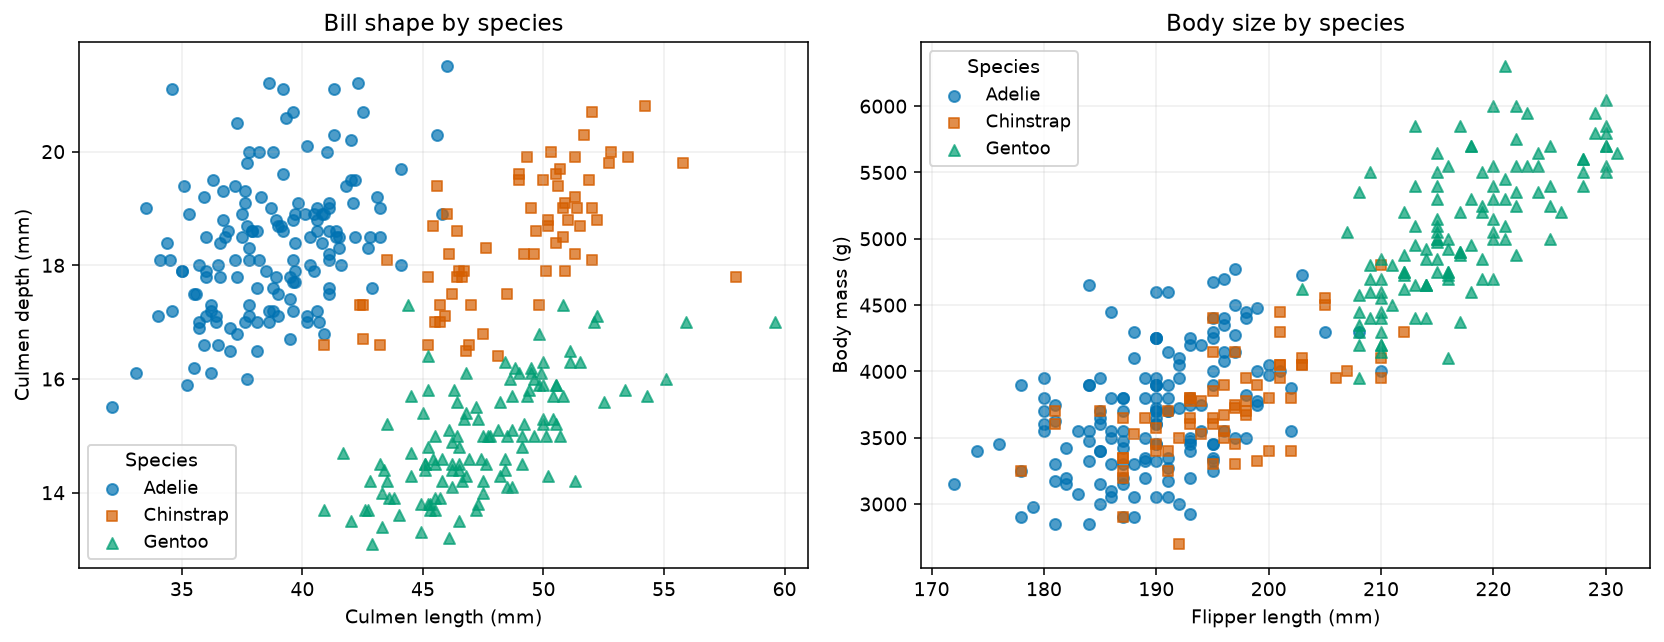

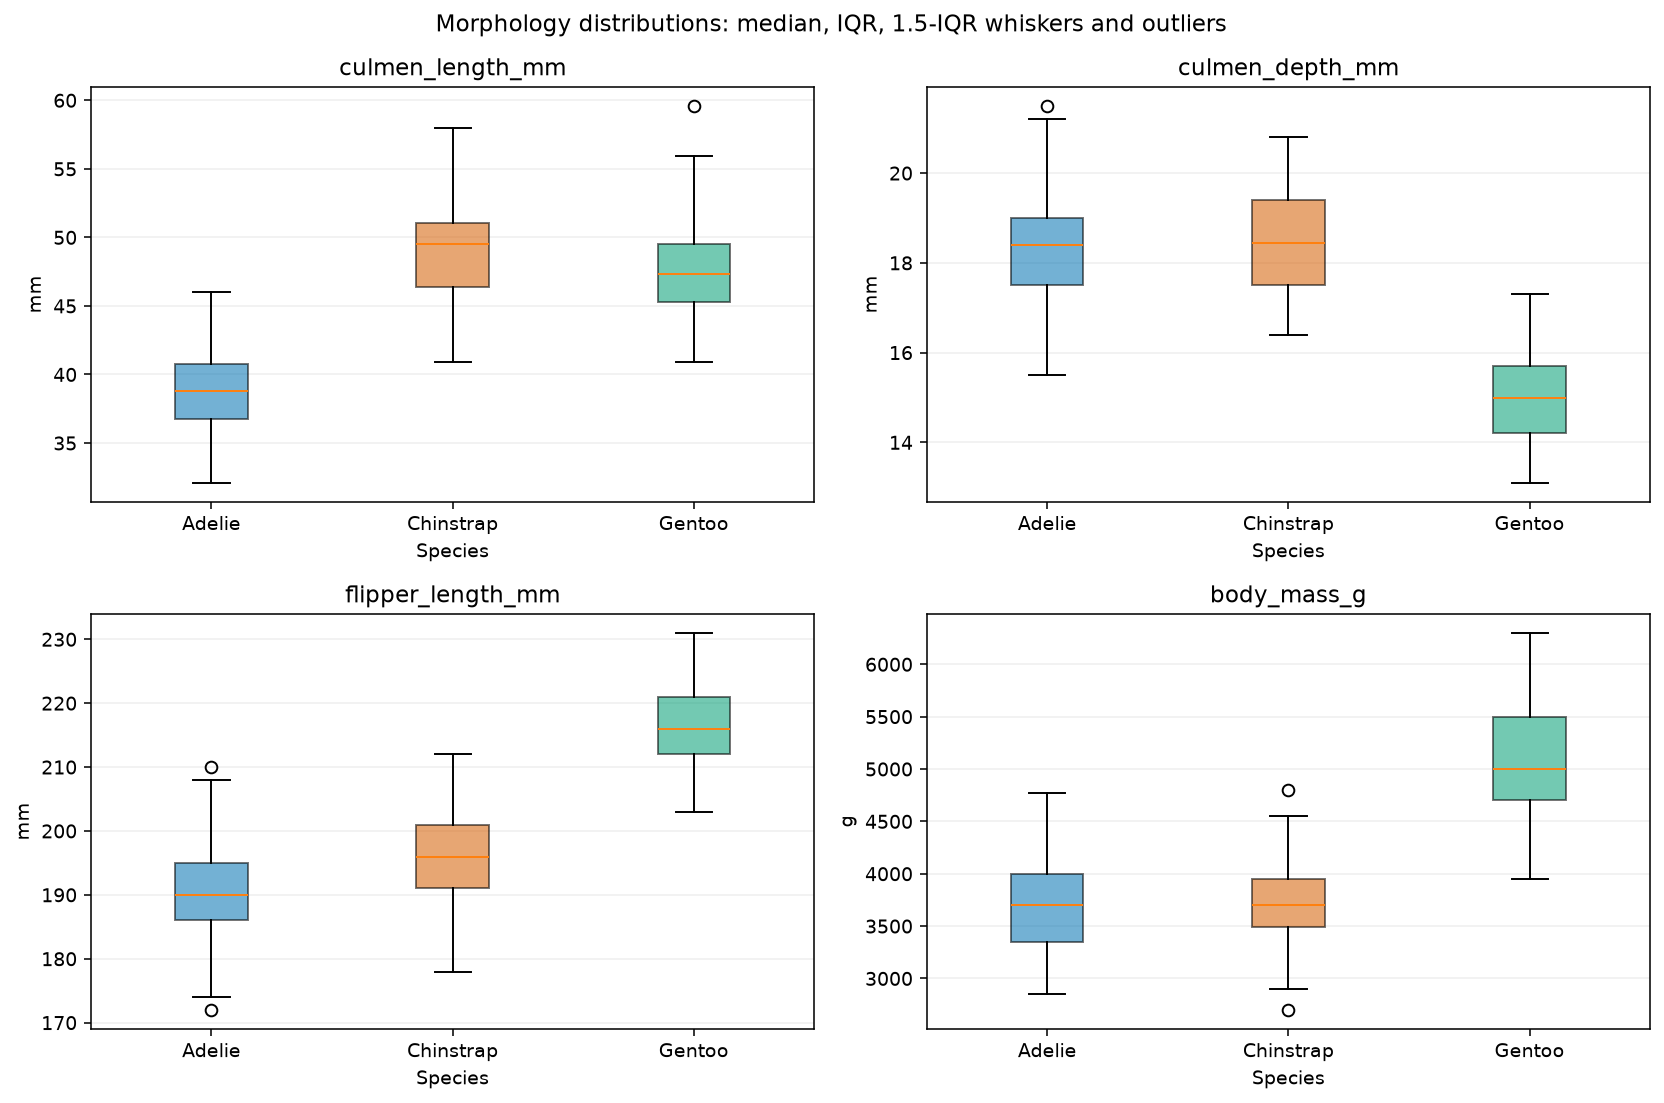

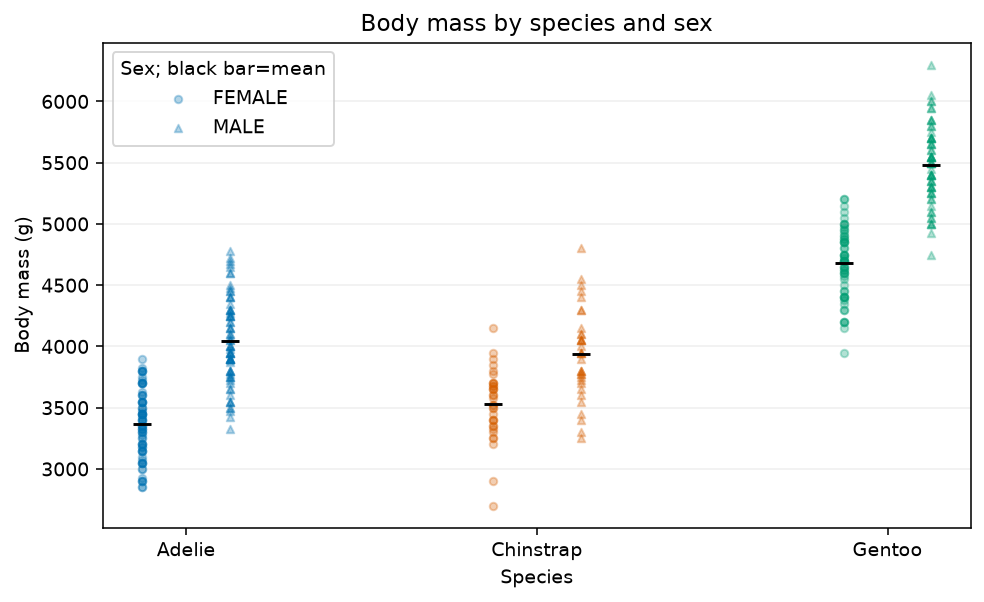

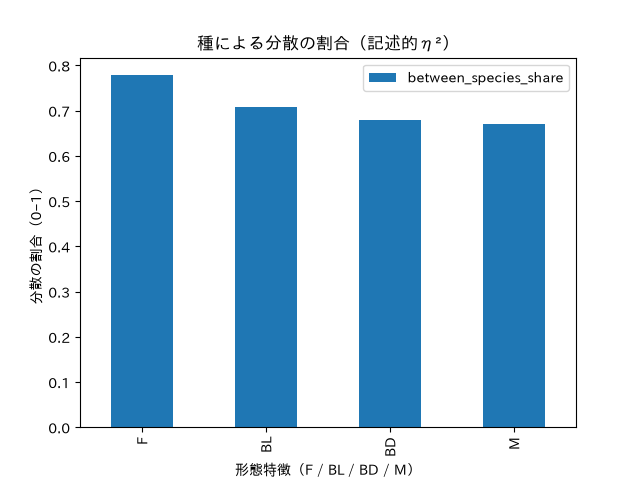

In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import base64
from ai_data_scientist import visualization
with phase('execution'):
    palette = {'Adelie':'#0072B2', 'Chinstrap':'#D55E00', 'Gentoo':'#009E73'}
    marker_map = {'Adelie':'o', 'Chinstrap':'s', 'Gentoo':'^'}
    plot_metadata = {}
    glyph_warnings = []
    def show_chart(fig, key, labels):
        buffer = io.BytesIO()
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always')
            fig.savefig(buffer, format='png', dpi=140, bbox_inches='tight')
        missing = [str(w.message) for w in caught if 'Glyph' in str(w.message) and 'missing' in str(w.message)]
        glyph_warnings.extend(missing)
        if missing:
            raise RuntimeError('図の欠落グリフを検出: ' + str(missing))
        image_output = visualization.build_image_output(buffer.getvalue())
        display({'image/png':image_output['data']['image/png'], 'text/plain':key}, raw=True)
        plot_metadata[key] = {**labels, 'missing_glyphs': [], 'glyph_check':'savefigの警告を実際に収集', 'png_bytes':len(buffer.getvalue())}
        plt.close(fig)
    fig, axes = plt.subplots(1,2,figsize=(12,4.7))
    for species, g in morph.groupby('species'):
        axes[0].scatter(g.culmen_length_mm,g.culmen_depth_mm,s=32,c=palette[species],marker=marker_map[species],alpha=.7,label=species)
        axes[1].scatter(g.flipper_length_mm,g.body_mass_g,s=32,c=palette[species],marker=marker_map[species],alpha=.7,label=species)
    for ax, title, x, y in zip(axes,['Bill shape by species','Body size by species'],['Culmen length (mm)','Flipper length (mm)'],['Culmen depth (mm)','Body mass (g)']):
        ax.set(title=title,xlabel=x,ylabel=y)
        ax.legend(title='Species',fontsize=9)
        ax.grid(alpha=.2)
    fig.tight_layout()
    show_chart(fig,'Species scatterplots',{'title':'Bill shape / Body size by species','xlabel':'Culmen length (mm) / Flipper length (mm)','ylabel':'Culmen depth (mm) / Body mass (g)','legend':'Adelie, Chinstrap, Gentoo'})
    fig, axes = plt.subplots(2,2,figsize=(12,8))
    for ax, feature in zip(axes.flat,measurements):
        vals = [morph.loc[morph.species.eq(s),feature] for s in species_order]
        box = ax.boxplot(vals,tick_labels=species_order,patch_artist=True,showfliers=True)
        for patch, s in zip(box['boxes'],species_order):
            patch.set(facecolor=palette[s],alpha=.55)
        ax.set(title=feature,xlabel='Species',ylabel='g' if feature=='body_mass_g' else 'mm')
        ax.grid(axis='y',alpha=.2)
    fig.suptitle('Morphology distributions: median, IQR, 1.5-IQR whiskers and outliers')
    fig.tight_layout()
    show_chart(fig,'Morphology boxplots',{'title':'Morphology distributions','xlabel':'Species','ylabel':'mm / g','legend':'Species on x-axis; box=IQR, line=median, points=outliers'})
    fig, ax = plt.subplots(figsize=(8,4.5))
    for i, s in enumerate(species_order):
        for j, sex in enumerate(['FEMALE','MALE']):
            v = sex_complete.loc[sex_complete.species.eq(s)&sex_complete.sex.eq(sex),'body_mass_g']
            ax.scatter(np.full(len(v),i+(j-.5)*.25),v,s=15,alpha=.3,c=palette[s],marker='o' if sex=='FEMALE' else '^',label=sex if i==0 else None)
            ax.scatter(i+(j-.5)*.25,v.mean(),s=90,c='black',marker='_')
    ax.set(xticks=range(3),xticklabels=species_order,title='Body mass by species and sex',xlabel='Species',ylabel='Body mass (g)')
    ax.legend(title='Sex; black bar=mean')
    ax.grid(axis='y',alpha=.2)
    show_chart(fig,'Sex-stratified body mass',{'title':'Body mass by species and sex','xlabel':'Species','ylabel':'Body mass (g)','legend':'FEMALE circle, MALE triangle, black bar=mean'})
    avg = effects.rename(columns={'eta_squared':'between_species_share'}).copy()
    avg['feature'] = avg['feature'].map({'flipper_length_mm':'F','culmen_length_mm':'BL','culmen_depth_mm':'BD','body_mass_g':'M'})
    png = visualization.render_chart(avg,kind='bar',x='feature',y='between_species_share',title='種による分散の割合（記述的η²）',xlabel='形態特徴（F / BL / BD / M）',ylabel='分散の割合（0–1）')
    display({'image/png':visualization.build_image_output(png)['data']['image/png'], 'text/plain':'Species variance shares'},raw=True)
    plot_metadata['Species variance shares']={'title':'種による分散の割合','xlabel':'形態特徴','ylabel':'分散の割合','legend':'between_species_share','missing_glyphs':[],'glyph_check':'日本語フォントをrender_chartで適用'}
    print('図表メタデータ:',json.dumps(plot_metadata,ensure_ascii=False))
    print('図の限界: 散布図の点の重なり、箱ひげ図の外れ値は削除根拠ではない。η²はこの標本の種構成に依存し分類精度ではない。英語ラベルで単位を明示、日本語解説は本文。')


## 反復依頼履歴：反復1

### 追加依頼文（原文）
種別の体格差と全体の強いフリッパー長・体重相関が、性別・島・年の構成による見かけの差ではないか確認してください。種×性別に層別した相関、種・性別・年を残差化した相関、性別と年を等重みにした比較、同じ島内での比較を実行し、平均と中央値・性別欠損の扱いを変えた感度分析で主要な差の方向と大きさを確認してください。島と種が完全に交絡する比較では、識別できないことを明示してください。

### 選定理由
初回で全体相関が種内相関より強く、全種に性差があり、島と種の観測が偏っている。関連を「個体の体格差」と読む際の構成効果を解消する必要がある。初回の根拠はinitialセルの相関表・性差表、qualityセルの種×島表。

### 結果・証拠・残る限界
この直後のiteration1セルに全層別相関、残差相関、同島比較、8仕様の感度結果を記録する。追加の因果識別や未観測島への外挿はできない。結果に基づく解釈は後続の根拠付きInsightを参照。

GentooとChinstrapは同じ島に観測されず、種と島の分離は識別不能。全種を含むspecies+islandモデルの係数を因果効果と解釈しない。
感度分析manifest（全8仕様・各差）: {
  "Gentoo-Adelie/body_mass_g": {
    "results": [
      {
        "specification": {
          "estimator": "mean",
          "subset": "morph",
          "weighting": "observed"
        },
        "value": 1375.3540085069726
      },
      {
        "specification": {
          "estimator": "mean",
          "subset": "morph",
          "weighting": "equal_sex"
        },
        "value": 1376.1243388804132
      },
      {
        "specification": {
          "estimator": "mean",
          "subset": "sex_known",
          "weighting": "observed"
        },
        "value": 1386.2725912282726
      },
      {
        "specification": {
          "estimator": "mean",
          "subset": "sex_known",
          "weighting": "equal_sex"
        },
        "value": 1376.1243388804132
      },
      {
        "specification": {
          "estimator": "median",
          "subset": "morph",
 

,species,sex,n,method,r
0,Adelie,FEMALE,73,pearson,0.26293
1,Adelie,FEMALE,73,spearman,0.24489
2,Adelie,MALE,73,pearson,0.36043
3,Adelie,MALE,73,spearman,0.40111
4,Chinstrap,FEMALE,34,pearson,0.24215
5,Chinstrap,FEMALE,34,spearman,0.25837
6,Chinstrap,MALE,34,pearson,0.66459
7,Chinstrap,MALE,34,spearman,0.67558
8,Gentoo,FEMALE,58,pearson,0.48762
9,Gentoo,FEMALE,58,spearman,0.52664


{'調整相関': {'partial_r_species_sex_year': 0.384435,
  'n': 333,
  'design_rank': 6,
  'design_columns': 6}}

,island,contrast,feature,equal_sex_year_difference,shared_cells,n_a,n_b
0,Biscoe,Gentoo - Adelie,culmen_length_mm,8.6018,6,119,44
1,Biscoe,Gentoo - Adelie,culmen_depth_mm,-3.4286,6,119,44
2,Biscoe,Gentoo - Adelie,flipper_length_mm,29.0943,6,119,44
3,Biscoe,Gentoo - Adelie,body_mass_g,1382.6029,6,119,44
4,Dream,Chinstrap - Adelie,culmen_length_mm,10.3386,6,68,55
5,Dream,Chinstrap - Adelie,culmen_depth_mm,0.1814,6,68,55
6,Dream,Chinstrap - Adelie,flipper_length_mm,6.0929,6,68,55
7,Dream,Chinstrap - Adelie,body_mass_g,41.9195,6,68,55


,contrast_feature,stable,max_relative_deviation,min_difference,max_difference
0,Gentoo-Adelie/body_mass_g,True,0.054789,1300.000,1400.000000
1,Gentoo-Chinstrap/body_mass_g,True,0.031966,1300.000,1359.348739
2,Gentoo-Adelie/flipper_length_mm,True,0.045288,26.000,27.233349
3,Gentoo-Chinstrap/flipper_length_mm,True,0.063822,20.000,21.411765
4,Chinstrap-Adelie/culmen_length_mm,True,0.070458,9.825,10.750000
5,Gentoo-Adelie/culmen_depth_mm,True,0.026527,-3.400,-3.275000


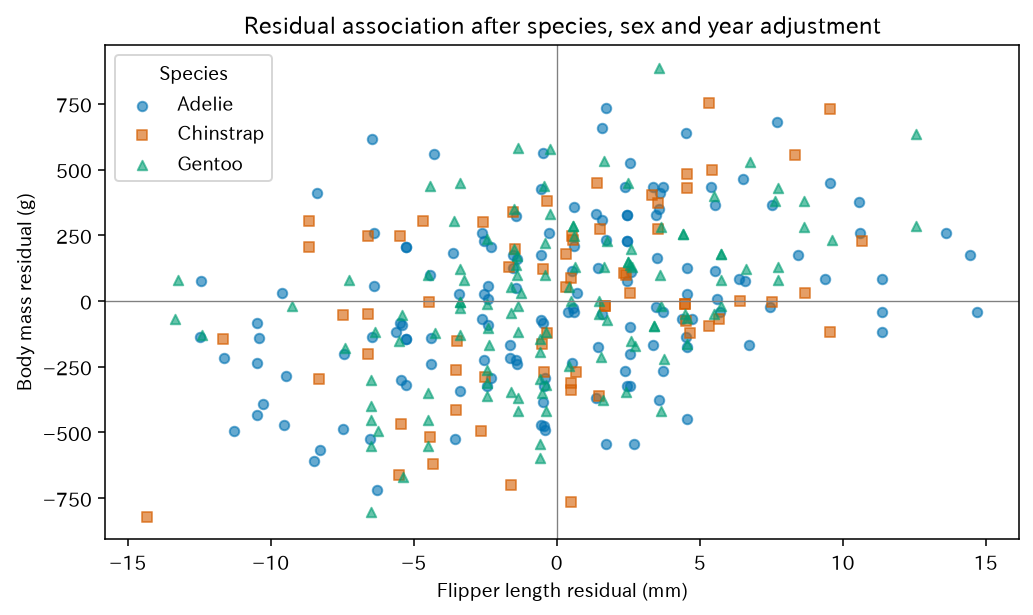

{'ITERATION1': {'partial_r': 0.384435,
  'all_main_contrasts_stable': True,
  'max_relative_deviation': 0.070458,
  'same_island_mass_differences': [{'island': 'Biscoe',
    'contrast': 'Gentoo - Adelie',
    'feature': 'body_mass_g',
    'equal_sex_year_difference': 1382.602867,
    'shared_cells': 6,
    'n_a': 119,
    'n_b': 44},
   {'island': 'Dream',
    'contrast': 'Chinstrap - Adelie',
    'feature': 'body_mass_g',
    'equal_sex_year_difference': 41.919516,
    'shared_cells': 6,
    'n_a': 68,
    'n_b': 55}]}}

In [6]:
from ai_data_scientist import sensitivity
with phase('execution'):
    strata_corr = []
    for (species,sex),g in sex_complete.groupby(['species','sex']):
        for method in ['pearson','spearman']:
            r = g.flipper_length_mm.corr(g.body_mass_g,method=method)
            strata_corr.append({'species':species,'sex':sex,'n':len(g),'method':method,'r':r})
    strata_corr = pd.DataFrame(strata_corr)
    display(strata_corr.round(5))
    Z = pd.get_dummies(sex_complete[['species','sex','year']].astype('str'), drop_first=True, dtype=float)
    Z.insert(0,'intercept',1.0)
    z = Z.to_numpy()
    residuals = {}
    for c in ['flipper_length_mm','body_mass_g']:
        y = sex_complete[c].to_numpy()
        residuals[c] = y-z@np.linalg.lstsq(z,y,rcond=None)[0]
    partial_r = np.corrcoef(residuals['flipper_length_mm'],residuals['body_mass_g'])[0,1]
    display({'調整相関': {'partial_r_species_sex_year': round(float(partial_r),6), 'n':len(sex_complete), 'design_rank':int(np.linalg.matrix_rank(z)), 'design_columns':z.shape[1]}})
    same_island = []
    for island,a,b in [('Biscoe','Gentoo','Adelie'),('Dream','Chinstrap','Adelie')]:
        subset = sex_complete.query('island == @island')
        for feature in measurements:
            means = subset.groupby(['species','sex','year'])[feature].mean()
            cells = means.loc[a].index.intersection(means.loc[b].index)
            difference = (means.loc[a].loc[cells]-means.loc[b].loc[cells]).mean()
            same_island.append({'island':island,'contrast':a+' - '+b,'feature':feature,'equal_sex_year_difference':difference,'shared_cells':len(cells),'n_a':int(subset.species.eq(a).sum()),'n_b':int(subset.species.eq(b).sum())})
    same_island = pd.DataFrame(same_island)
    display(same_island.round(4))
    print('GentooとChinstrapは同じ島に観測されず、種と島の分離は識別不能。全種を含むspecies+islandモデルの係数を因果効果と解釈しない。')
    plan1 = sensitivity.SensitivityPlan({'estimator':['mean','median'],'subset':['morph','sex_known'],'weighting':['observed','equal_sex']}, max_runs=8)
    def contrast_spec(a,b,feature,estimator,subset,weighting):
        frame = morph if subset=='morph' else sex_complete
        if weighting=='equal_sex':
            frame = frame[frame.sex.notna()]
            agg = frame.groupby(['species','sex'])[feature].agg(estimator).groupby('species').mean()
        else:
            agg = frame.groupby('species')[feature].agg(estimator)
        return float(agg[a]-agg[b])
    sensitivity_reports = {}
    for a,b,feature in [('Gentoo','Adelie','body_mass_g'),('Gentoo','Chinstrap','body_mass_g'),('Gentoo','Adelie','flipper_length_mm'),('Gentoo','Chinstrap','flipper_length_mm'),('Chinstrap','Adelie','culmen_length_mm'),('Gentoo','Adelie','culmen_depth_mm')]:
        report_s = sensitivity.run_sensitivity(plan1,lambda **spec:contrast_spec(a,b,feature,**spec),stability_tolerance=.2)
        sensitivity_reports[a+'-'+b+'/'+feature]=asdict(report_s)
    print('感度分析manifest（全8仕様・各差）:',json.dumps(sensitivity_reports,ensure_ascii=False,indent=2))
    sensitivity_summary = pd.DataFrame([{'contrast_feature':key,'stable':report['stable'],'max_relative_deviation':report['max_relative_deviation'],'min_difference':min(x['value'] for x in report['results']),'max_difference':max(x['value'] for x in report['results'])} for key,report in sensitivity_reports.items()])
    display(sensitivity_summary.round(6))
    fig,ax=plt.subplots(figsize=(7.5,4.5))
    for species,g in sex_complete.groupby('species'):
        idx=g.index
        pos=sex_complete.index.get_indexer(idx)
        ax.scatter(residuals['flipper_length_mm'][pos],residuals['body_mass_g'][pos],label=species,c=palette[species],marker=marker_map[species],s=24,alpha=.6)
    ax.axhline(0,c='grey',lw=.7); ax.axvline(0,c='grey',lw=.7)
    ax.set(title='Residual association after species, sex and year adjustment',xlabel='Flipper length residual (mm)',ylabel='Body mass residual (g)')
    ax.legend(title='Species')
    fig.tight_layout()
    show_chart(fig,'Adjusted association',{'title':'Residual association after species, sex and year adjustment','xlabel':'Flipper length residual (mm)','ylabel':'Body mass residual (g)','legend':'Adelie, Chinstrap, Gentoo'})
    display({'ITERATION1': {'partial_r':round(float(partial_r),6),'all_main_contrasts_stable':bool(sensitivity_summary.stable.all()),'max_relative_deviation':round(float(sensitivity_summary.max_relative_deviation.max()),6),'same_island_mass_differences':same_island.query("feature=='body_mass_g'").round(6).to_dict('records')}})


## 反復依頼履歴：反復2

### 追加依頼文（原文）
反復1で主要差の方向は安定しましたが、個体IDの反復と欠損が不確実性を過小評価していないか追加確認してください。種・島を含むIDの年越し反復と性別の整合性を調べ、ID単位・巣番号らしい接頭辞単位でクラスターブートストラップした主要差と性差の区間を比較してください。形態欠損を観測範囲の上下限に置く感度分析、1%ウィンズライジング、性別不明の全割当を実施し、確かな結論とデータだけでは解消できない独立性・欠損の仮定を区別してください。

### 選定理由
反復1では全体相関の解釈を修正し、6つの主要差は8仕様とも安定した。しかしqualityセルでID反復が多く、初回区間の独立性仮定は未解決。性不明を除外するだけでは欠損の任意性を確認できない。

### 結果・証拠・残る限界
直後のiteration2セルでID診断、3代理クラスタの95%区間、性別未知の全割当、形態欠損の上下限補完と1%ウィンズライジングを実行する。代理クラスタは真の抽出設計を復元しない。結果は後続の根拠付きInsightに解釈を記録。

In [7]:
import itertools
with phase('execution'):
    id_summary = morph.groupby(['species','island','individual_id']).agg(rows=('year','size'),years=('year','nunique'),sex_values=('sex','nunique'))
    print('種・島・IDによるキー診断:', {'groups':len(id_summary),'repeated_groups':int(id_summary.rows.gt(1).sum()),'multiyear_groups':int(id_summary.years.gt(1).sum()),'sex_inconsistent_groups':int(id_summary.sex_values.gt(1).sum())})
    display(id_summary.query('sex_values > 1').head(6))
    print('IDは恒久個体識別子とは確認できない。年越し再利用・記録誤差・同一個体の区別は不能。巣接頭辞はA+数字の末尾を除く推定であり未検証。')
    rng2 = np.random.default_rng(SEED+1)
    B2 = 4000
    def cluster_labels(g,scheme):
        nest = g.individual_id.str.replace(r'A[0-9]+$','',regex=True)
        if scheme=='individual_id':
            return g.island.astype(str)+'/'+g.individual_id.astype(str)
        if scheme=='nest_year':
            return g.island.astype(str)+'/'+g.year.astype(str)+'/'+nest.astype(str)
        return g.island.astype(str)+'/'+nest.astype(str)
    def cluster_means(g,feature,scheme):
        groups=g[feature].groupby(cluster_labels(g,scheme)).agg(['sum','count'])
        draws=rng2.integers(0,len(groups),size=(B2,len(groups)))
        return groups['sum'].to_numpy()[draws].sum(1)/groups['count'].to_numpy()[draws].sum(1),len(groups)
    cluster_results=[]
    main_comparisons=[('Gentoo','Adelie','body_mass_g'),('Gentoo','Chinstrap','body_mass_g'),('Chinstrap','Adelie','culmen_length_mm'),('Gentoo','Adelie','flipper_length_mm')]
    for a,b,feature in main_comparisons:
        for scheme in ['individual_id','nest_year','nest_all_years']:
            ba,ga=cluster_means(morph.query('species==@a'),feature,scheme)
            bb,gb=cluster_means(morph.query('species==@b'),feature,scheme)
            delta=ba-bb
            cluster_results.append({'contrast':a+' - '+b,'feature':feature,'scheme':scheme,'clusters_a':ga,'clusters_b':gb,'ci_low':np.quantile(delta,.025),'ci_high':np.quantile(delta,.975)})
    cluster_results=pd.DataFrame(cluster_results)
    display(cluster_results.round(3))
    cluster_sex=[]
    for species,g in sex_complete.groupby('species'):
        labels=cluster_labels(g,'nest_all_years')
        sums=g.groupby([labels,g.sex]).body_mass_g.sum().unstack(fill_value=0).reindex(columns=['MALE','FEMALE'],fill_value=0)
        counts=g.groupby([labels,g.sex]).body_mass_g.count().unstack(fill_value=0).reindex(index=sums.index,columns=['MALE','FEMALE'],fill_value=0)
        draws=rng2.integers(0,len(sums),size=(B2,len(sums)))
        boot=sums.to_numpy()[draws].sum(1)/counts.to_numpy()[draws].sum(1)
        delta=boot[:,0]-boot[:,1]
        cluster_sex.append({'species':species,'clusters':len(sums),'ci_low':np.quantile(delta,.025),'ci_high':np.quantile(delta,.975)})
    cluster_sex=pd.DataFrame(cluster_sex)
    display(cluster_sex.round(3))
    missing_sex_bounds=[]
    for species,g in morph.groupby('species'):
        unknown=g.loc[g.sex.isna(),'body_mass_g'].to_numpy()
        known_m=g.loc[g.sex.eq('MALE'),'body_mass_g'].to_numpy();known_f=g.loc[g.sex.eq('FEMALE'),'body_mass_g'].to_numpy()
        values=[]
        for assignment in itertools.product([False,True],repeat=len(unknown)):
            male_mask=np.array(assignment,dtype=bool)
            m=np.concatenate([known_m,unknown[male_mask]])
            f=np.concatenate([known_f,unknown[~male_mask]])
            values.append(float(m.mean()-f.mean()))
        missing_sex_bounds.append({'species':species,'unknown_morph_n':len(unknown),'assignments':len(values),'min_male_minus_female_g':min(values),'max_male_minus_female_g':max(values)})
    missing_sex_bounds=pd.DataFrame(missing_sex_bounds)
    display(missing_sex_bounds.round(3))
    plan2=sensitivity.SensitivityPlan({'processing':['complete','winsor_1pct','missing_low_high','missing_high_low']},max_runs=4)
    def quality_contrast(a,b,feature,processing):
        frame=df.copy()
        if processing.startswith('missing_'):
            low_high=processing=='missing_low_high'
            for species,upper in [(a,not low_high),(b,low_high)]:
                mask=frame.species.eq(species)
                observed=frame.loc[mask,feature].dropna()
                fill=observed.max() if upper else observed.min()
                frame.loc[mask,feature]=frame.loc[mask,feature].fillna(fill)
        else:
            frame=morph.copy()
        if processing=='winsor_1pct':
            frame[feature]=frame.groupby('species')[feature].transform(lambda x:x.clip(x.quantile(.01),x.quantile(.99)))
        means=frame.groupby('species')[feature].mean()
        return float(means[a]-means[b])
    reports2={}
    for a,b,feature in main_comparisons:
        r=sensitivity.run_sensitivity(plan2,lambda **s:quality_contrast(a,b,feature,**s),stability_tolerance=.2)
        reports2[a+'-'+b+'/'+feature]=asdict(r)
    print('反復2感度manifest:',json.dumps(reports2,ensure_ascii=False,indent=2))
    sensitivity2_summary=pd.DataFrame([{'contrast_feature':key,'stable':r['stable'],'max_relative_deviation':r['max_relative_deviation'],'min_difference':min(x['value'] for x in r['results']),'max_difference':max(x['value'] for x in r['results'])} for key,r in reports2.items()])
    display(sensitivity2_summary.round(6))
    assumption_manifest_final=analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope=assumption_manifest.analysis_scope,
        assumptions=(analysis_assumptions.Assumption('missing','観測値範囲内の形態補完・性不明全割当で主要差の方向が安定','tested',impact_if_false='観測範囲外の欠損値なら追加の偏りは残る'),analysis_assumptions.Assumption('independence','真の恒久個体IDと巣クラスタが不明であり、独立性を確定できない','assumed',conclusion_critical=True,impact_if_false='提示した区間が過度に狭い可能性'),analysis_assumptions.Assumption('cluster_sensitivity','3種類の代理クラスタの区間を比較','tested'),analysis_assumptions.Assumption('causal','種・島・性別の関連は因果と主張しない','verified'),analysis_assumptions.Assumption('population','取得標本に限定し母集団代表性を主張しない','verified')),
        causal_scope='associational',sampling={'n':len(morph),'seed':SEED})
    print('最終分析前提manifest:',json.dumps(asdict(assumption_manifest_final),ensure_ascii=False,indent=2))
    print('最終前提の全finding:',[asdict(x) for x in analysis_assumptions.check_manifest(assumption_manifest_final)])
    display({'ITERATION2':{'cluster_all_main_ci_positive':bool(cluster_results.ci_low.gt(0).all()),'cluster_sex_ci_positive':bool(cluster_sex.ci_low.gt(0).all()),'all_sex_assignments_positive':bool(missing_sex_bounds.min_male_minus_female_g.gt(0).all()),'sensitivity_stable':bool(sensitivity2_summary.stable.all()),'max_relative_deviation':round(float(sensitivity2_summary.max_relative_deviation.max()),6),'sex_inconsistent_id_groups':int(id_summary.sex_values.gt(1).sum())}})


種・島・IDによるキー診断: {'groups': 303, 'repeated_groups': 39, 'multiyear_groups': 39, 'sex_inconsistent_groups': 8}
IDは恒久個体識別子とは確認できない。年越し再利用・記録誤差・同一個体の区別は不能。巣接頭辞はA+数字の末尾を除く推定であり未検証。
反復2感度manifest: {
  "Gentoo-Adelie/body_mass_g": {
    "results": [
      {
        "specification": {
          "processing": "complete"
        },
        "value": 1375.3540085069726
      },
      {
        "specification": {
          "processing": "winsor_1pct"
        },
        "value": 1374.7065632907984
      },
      {
        "specification": {
          "processing": "missing_low_high"
        },
        "value": 1359.2052207130732
      },
      {
        "specification": {
          "processing": "missing_high_low"
        },
        "value": 1390.821307300509
      }
    ],
    "baseline_value": 1375.3540085069726,
    "stable": true,
    "max_relative_deviation": 0.011741549952967984
  },
  "Gentoo-Chinstrap/body_mass_g": {
    "results": [
      {
        "specification": {
          "processing": 

rows  years  sex_values
species   island individual_id                         
Chinstrap Dream  N62A1             2      2           2
                 N62A2             2      2           2
                 N67A1             2      2           2
                 N67A2             2      2           2
Gentoo    Biscoe N20A1             2      2           2
                 N20A2             2      2           2

,contrast,feature,scheme,clusters_a,clusters_b,ci_low,ci_high
0,Gentoo - Adelie,body_mass_g,individual_id,94,151,1250.555,1501.743
1,Gentoo - Adelie,body_mass_g,nest_year,62,76,1301.130,1446.218
2,Gentoo - Adelie,body_mass_g,nest_all_years,47,76,1301.926,1447.896
3,Gentoo - Chinstrap,body_mass_g,individual_id,94,58,1196.344,1480.819
4,Gentoo - Chinstrap,body_mass_g,nest_year,62,34,1253.363,1425.142
5,Gentoo - Chinstrap,body_mass_g,nest_all_years,47,29,1256.828,1431.056
6,Chinstrap - Adelie,culmen_length_mm,individual_id,58,151,9.147,10.902
7,Chinstrap - Adelie,culmen_length_mm,nest_year,34,76,9.451,10.677
8,Chinstrap - Adelie,culmen_length_mm,nest_all_years,29,76,9.429,10.653
9,Gentoo - Adelie,flipper_length_mm,individual_id,94,151,25.514,28.859


,species,clusters,ci_low,ci_high
0,Adelie,74,584.555,769.384
1,Chinstrap,29,223.438,595.843
2,Gentoo,47,696.066,916.179


,species,unknown_morph_n,assignments,min_male_minus_female_g,max_male_minus_female_g
0,Adelie,5,32,627.171,677.777
1,Chinstrap,0,1,411.765,411.765
2,Gentoo,4,16,749.874,811.046


,contrast_feature,stable,max_relative_deviation,min_difference,max_difference
0,Gentoo-Adelie/body_mass_g,True,0.011742,1359.205221,1390.821307
1,Gentoo-Chinstrap/body_mass_g,True,0.007350,1333.847249,1352.798861
2,Chinstrap-Adelie/culmen_length_mm,True,0.004722,9.995008,10.086455
3,Gentoo-Adelie/flipper_length_mm,True,0.009044,26.987054,27.462861


{'ITERATION2': {'cluster_all_main_ci_positive': True,
  'cluster_sex_ci_positive': True,
  'all_sex_assignments_positive': True,
  'sensitivity_stable': True,
  'max_relative_deviation': 0.011742,
  'sex_inconsistent_id_groups': 8}}

## 反復の終了判断・限界

反復2の結果を再読した。主要な種差はクラスタ区間が全て正、性差は不明性別の全割当でも正、欠損・ウィンズライジングの変動は小さい。一方、島と種の非重複、恒久個体ID／真の抽出設計、測定手順、観測範囲外の欠損値はこのデータだけでは識別できない。追加の同じ標本のモデルを増やしても解消しないため、価値ある追加分析がなくなったと判断し2回で停止する（最大3回の枠内）。分類精度や因果的種効果を主張するための追加分析は行わない。

最終前提manifestのcheck_manifestはindependenceについてwarningを返す。代理クラスタ区間は独立性の証明ではなく、一部の巣クラスタ区間はペアの正負依存により初回より狭くなる。複数仕様における方向の維持と、標本抽出由来の不確実性の完全な定量化は区別する。

全ての95%区間は探索的で多重性未補正。調整相関は線形・加法的な残差化で、島と種を完全に分離しない。η²は観測種構成に依存する記述的分散比で、分類精度・因果説明率ではない。AdelieとChinstrapの体重差の区間が0を含むことは「同じ体重」の証明ではない。代表性、測定プロトコル、性判定法、恒久IDの意味は不明。データ取得日（2026年）と観測年（2007–2009年）は別で、現在の野生個体群への外挿はしない。

### 再実行の確認方式
全コードセルをカーネル再起動後にJupyter MCP execute_cellで上から順に実行する。根拠準備セルで当回の引用値を抽出し、外側MCPセルからrecord_insightでInsightと図表メタデータを保存した後、最後の読み取り専用セルで監査する。自身のまだ保存前の最終セルは監査仕様の対象外となることがあるため、全セル保存後に外側のJupyter MCPセルでも再監査し、最終報告をNotebook metadata.analysis_runに永続化する。

## 使用したJupytermindモジュール

直接import・呼び出したものだけを記録する（間接利用は含めない）。

| モジュール | 直接呼び出した関数・クラス | 使用目的 |
|---|---|---|
| ai_data_scientist.project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | slug検証、指定保存先の作成、データ配置、追記とメタデータの直列化 |
| ai_data_scientist.language_router | detect_language | 日本語出力の確認 |
| ai_data_scientist.lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_completed, mark_failed, get_run_status, wait_for_quiescence | run_id登録、フェーズ、失敗・完了・静止状態 |
| ai_data_scientist.ingestion | SourceSpec, ingest | Kaggle取得後のCSVを上限1000行で読み込む |
| ai_data_scientist.cleaning | clean_dataset | 形態／性別完全例の除外行数を明示 |
| ai_data_scientist.eda | explore | 型、欠損数・率、カテゴリ分布 |
| ai_data_scientist.data_quality | detect_anomalies | 範囲、カテゴリ、必須値の意味的検査 |
| ai_data_scientist.data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 単位・定義・出典・未知情報の確度分離 |
| ai_data_scientist.analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 記述・関連の範囲、独立性と欠損前提の警告 |
| ai_data_scientist.stats_analysis | correlation | 全体・種別Pearson相関と日本語解釈 |
| ai_data_scientist.visualization | render_chart, build_image_output | 日本語η²図と全PNGのMIME出力 |
| ai_data_scientist.sensitivity | SensitivityPlan, run_sensitivity | 8仕様・4仕様、許容相対変化20%の監査 |
| ai_data_scientist.insight_engine | extract_cited_value, record_insight | 実行済みセル出力から引用値を抽出し、根拠manifest付き解釈を記録 |
| ai_data_scientist.notebook_audit | audit_notebook, audit_visual_outputs | visual_audit=Trueとメタデータ欠落の再現プローブ |

### 適用しない機能・実行方式
mcp_gateway.run_and_recordは直接import／呼び出していない。ホスト側Jupyter MCPツールを直接呼び、同じカーネルのNotebook内から実行要求を再入させるクライアントは用意しない。偽のexecuteクライアントやPython execで代替しない。Notebookの計画・コード・Insight・メタデータ追加はenqueue_write、実行と出力保存はJupyter MCP execute_cellが担当する。初期空ファイルはensure_notebookで作成。補助NotebookはJupyter MCP経由の書込み制御だけに使い、分析そのものは本Notebookのセルで実行した。

独立参照データがないためdata_quality.validate_anomaliesとdataset_validation.compare_datasetsは使用しない。簡易CSV・詳細CSVは同一標本であり独立検証と呼ばない。anomaly_detectionのzスコアで生物学的に有効な極端個体を削除しない。ML拡張・自動データ発見・因果推論は目的／情報不足により適用しない。

## Jupytermind改善候補

### 候補1：可視化監査が空のchartメタデータを見逃す（監査の機能不足）
- 再現条件：実際のPNGを持つコードセルからmetadata.chartを削除し、notebook_audit.audit_visual_outputsを呼ぶ。最終evidence_auditセルの「VISUAL_METADATA_PROBE」が再現ログ。
- 期待：missing_glyphs/title/xlabel/ylabel/legendの監査に必要なメタデータ欠落をfindingとして知らせる。
- 実際：chart_metadataが空ならラベル検査がスキップされ、missing_glyphsの不在も指摘せず、非空PNGなら空tupleを返す（最終セルで実測）。
- 影響：visual_audit=Trueのokだけで全図の読めるラベル・グリフを保証できない。
- 回避策：本Notebookでは実図の警告を収集し、chartメタデータとchart_detailsを明示する。図も目視確認した。ピクセル単位のレイアウト監査ではないことを明記する。
- 関係するセルとログ：charts／iteration1の図、evidence_auditのVISUAL_METADATA_PROBE・notebook_audit出力。Jupytermindの監査実装に起因しKaggle API・CLI・ランナーの問題とは別。

### 候補2：render_chartの長いx目盛名が下端で切れる（可視化のレイアウト機能不足）
- 再現条件：effectsの元の長いfeature名をxにしてkind=bar、title/xlabel/ylabel付きでrender_chart。初回描画では縦向きのculmen/flipper/body_mass列名とx軸ラベルが下端に近づき切れた。
- 期待：tight_layoutまたはbbox_inches=tight相当でラベルをPNG内に収める。
- 実際：render_chartは標準サイズのsavefigのみで長い目盛の余白を調整しない。上記監査でもラベルの幾何学的欠落は検出しない。
- 影響：PNGの存在とラベル文字列の存在だけでは読みやすさを確認できない。
- 回避策：最終chartsセルではF/BL/BD/Mに短縮し、本文に凡例を記載。F=フリッパー長、BL=嘴長、BD=嘴深さ、M=体重。他図はtight_layout／bbox_inches=tightを使用。
- 関係するセルとログ：chartsの最初の実行（目視）と最終再実行（短縮後）。Jupytermindの描画APIの余白管理の改善候補であり、フォント・認証・ベンチマークランナーの問題ではない。

### 他システム／分析コードとの切分け
filesystem MCPはこのリポジトリを許可ディレクトリに含めず、初回の対象パスへのNotebook作成も親ディレクトリ未作成で失敗した。これはツールの作業領域設定と初期化の順序の問題で、Jupyter MCPの補助セル＋ensure_notebookで作成して解消。Jupytermind候補に含めない。
qualityの初回assertはpandasのstrとobjectの型差によるものだった。値は一致しており、分析コードの比較前にobjectへ正規化して解消した。Jupytermind候補に含めない。API認証・検索・取得は成功。CLI／Kaggle API／ベンチマークランナーの障害は観測していない。データ定義unresolved_fieldsは仕様どおりunknownのみを返すので、inferredは別途列挙した（不具合とは断定しない）。

Insight引用の初回正規表現で改行跨ぎを指定していなかったためCitedValueNotFoundErrorが発生した。改行対応に修正して再実行した。これは分析コードの問題であり、insight_engineが誤引用を拒否した正常動作。evidence_auditセルに旧エラーが残ったまま監査されないよう、旧エラーは再実行で置換し、保存後に外側から全セルを再監査する。実行中のセルのexecution_countやoutputsを手動リセットしない。

自己記録中に監査コードセルを末尾へ移動した初回実行では、Jupyter MCP側の保存時インデックスが変わり監査セルのexecution_countが未保存になった。書込み済みInsight用スロットを同じ位置・IDで置換する方式に変更し、実行中のコードセルを移動しないことで回避。これは実行中にセル構造を変えたオーケストレーション側の問題として切り分け、Jupytermind候補には含めない。最終確認では全コードの保存済みexecution_countを外側から確認する。

### 候補3：Jupyter MCP実行中のenqueue_writeとの保存競合（相互運用の改善候補、原因未確定）
- 再現条件：同じNotebookをexecute_cellで実行しながら、セル内部からenqueue_write／record_insightでそのNotebookを更新する。セル位置・ID固定、execution_countリセットなしでも再現。旧evidence_audit実行が実験ログ。
- 期待：成功した全コードセルの実行番号・出力が永続化される。
- 実際：正常終了・completedでも最後のセルがexecution_count=None。外側監査でcode_cell_count=8、executed_code_cell_count=7、ok=True（末尾監査セル除外のため）。
- 影響：実行・保存の完全性と監査okを誤解する危険。末尾セル除外のwarningは単に実行中を示すため、保存後は別確認が必要。
- 回避策：自己書込みを止め、引用準備を対象Notebook、enqueue_write／record_insightを外側のJupyter MCP補助セル、最後の監査を対象Notebookに分離。全セル保存後に実行数一致を検査する。
- 関係するセルとログ：旧evidence_audit、現在のevidence_preparation／final_audit、metadata.recording_issue_logとtop_to_bottom_reexecution。JupytermindとJupyter MCPの保存協調の候補であり、どちらか一方の不具合とは断定しない。CLI、Kaggle API、ランナーの問題とは分離する。

## 日本語の分析結果・根拠付きInsight

以下は実行セル出力から引用値を機械抽出しrecord_insightで保存する。再実行時に実行番号を更新する。

形態差の分析対象は342行（元344行から4形態欠損2行を除外）。性別既知の完全例は333行。不正性別「.」1件は性不明に変更し、範囲違反0件、完全重複0件だった。範囲は広い分析上の点検基準であって生物学的正常値の証明ではない。

```evidence
{"execution_count":3,"cited_value":"342","claim_type":"descriptive"}
```

Gentooの平均体重は5076.01626 g、平均フリッパー長217.187 mmで、Adelie（3700.662 g、189.954 mm）とChinstrap（3733.088 g、195.824 mm）より大型。Gentoo−Adelieの体重差は1375.354 g（行単位95%bootstrap区間1260.568–1487.100 g）、フリッパー差27.233 mm（25.651–28.769 mm）。ただし個体分布は一部重なり、種だけで全ての個体を識別できるとはいえない。

```evidence
{"execution_count":4,"cited_value":"5076.01626","claim_type":"descriptive"}
```

Chinstrapの平均嘴長は48.833824 mm、Adelieは38.791 mmで約10.042 mm異なる。一方、両種の体重差32.426 gの区間は−85.267–148.194 g、嘴深さ差0.074 mmの区間も0を含む。両種の区別には体重より嘴長が有用な記述的特徴。Gentooは嘴深さ14.982 mmで他2種の約18.35–18.42 mmより浅く、嘴長×深さの組合せで3群がよく分かれる。

```evidence
{"execution_count":4,"cited_value":"48.833824","claim_type":"descriptive"}
```

4特徴のうち種間の分散割合η²はフリッパー長が最大で0.778229。続いて嘴長0.707809、嘴深さ0.679759、体重0.669672。これは標本内の単変量差の強さで、分類性能や因果的な説明率ではない。日本語図の略号はF=フリッパー長、BL=嘴長、BD=嘴深さ、M=体重。

```evidence
{"execution_count":4,"cited_value":"0.778229","claim_type":"descriptive"}
```

全体のフリッパー長と体重の相関はr=0.871202。種内はAdelie 0.468202、Chinstrap 0.641559、Gentoo 0.702667で、全体の強さには種構成が含まれる。stats_analysisの解釈は「正の相関」であり、フリッパーが体重を増やす因果関係を意味しない。

```evidence
{"execution_count":4,"cited_value":"0.871202","claim_type":"associational"}
```

同じ種内でも雄の平均体重が雌より大きく、差はAdelie 674.658 g（探索的95%区間573.973–775.685 g）、Chinstrap 411.765 g（257.316–567.665 g）、Gentoo 805.095 g（699.828–912.576 g）。4形態特徴全てで雄の平均が大きい。種差と性差を混同せず、体重の比較は性別ごとにも行うべき。

```evidence
{"execution_count":4,"cited_value":"674.657534","claim_type":"descriptive"}
```

反復1：種・性別・年を線形残差化すると相関はr=0.384435まで低下する。種×性別のPearson相関は約0.242–0.665。関連は残るが、「全個体に非常に強い体格相関」という初回の読み方は修正が必要。島・非線形・相互作用の未調整は残る。

```evidence
{"execution_count":6,"cited_value":"0.384435","claim_type":"associational"}
```

反復1：平均／中央値×全形態完全例／性別既知例×観測重み／性別等重みの8仕様で、6つの主要差は全てstable=True。最大相対変化は0.070458（約7.05%、事前許容20%）。同島・性別×年等重みでもBiscoeのGentoo−Adelie体重差1382.603 g、DreamのChinstrap−Adelie嘴長差10.339 mm。GentooとChinstrapは島の重複がないため種と島の因果的な切分けは不能。

```evidence
{"execution_count":6,"cited_value":"0.070458","claim_type":"descriptive"}
```

反復2：3種類の代理クラスタで主要4比較の95%区間下限が全て正だった（cluster_all_main_ci_positive=True）。最も広いIDクラスタのGentoo−Adelie体重区間は1250.555–1501.743 g。性別不明の形態完全例を全割当しても雄−雌の体重差はAdelie 627.171–677.777 g、Gentoo 749.874–811.046 gで正。年越しIDの性別不一致が8群あり、恒久IDか番号再利用かを決定できない。独立性警告は解消したことにしない。

```evidence
{"execution_count":7,"cited_value":"True","claim_type":"descriptive"}
```

反復2：形態欠損を種内観測範囲の上下端に置いた2仕様、完全例、種内1%ウィンズライジングの4仕様で主要差は全てstable=True。最大相対変化0.011742（約1.17%）。観測範囲内での欠損と少数の極端値に結論が左右されにくいが、観測範囲外の欠損、抽出偏り、測定誤差は検証できない。

```evidence
{"execution_count":7,"cited_value":"0.011742","claim_type":"descriptive"}
```

In [8]:
from ai_data_scientist import insight_engine, notebook_audit
with phase('execution'):
    nb_snapshot=nbformat.read(handle.notebook_path,as_version=4)
    def evidence_result(tag):
        c=next(c for c in nb_snapshot.cells if c.metadata.get('analysis_tag')==tag)
        if c.execution_count is None or any(o.output_type=='error' for o in c.outputs):
            raise RuntimeError('根拠セルが正常実行済みでない: '+tag)
        text='\n'.join(str(o.get('data',{}).get('text/plain','')) for o in c.outputs)
        return {'output':text,'execution_count':c.execution_count}
    citations={
        'n':insight_engine.extract_cited_value(evidence_result('quality'),r"'morph_n': (\d+)"),
        'mass':insight_engine.extract_cited_value(evidence_result('initial'),r"(?s)'body_mass_g': \{.*?'Gentoo': ([0-9.]+)"),
        'eta':insight_engine.extract_cited_value(evidence_result('initial'),r"'eta_squared': \{'flipper_length_mm': ([0-9.]+)"),
        'bill':insight_engine.extract_cited_value(evidence_result('initial'),r"(?s)'culmen_length_mm': \{.*?'Chinstrap': ([0-9.]+)"),
        'r':insight_engine.extract_cited_value(evidence_result('initial'),r"'ALL': ([0-9.]+)"),
        'partial':insight_engine.extract_cited_value(evidence_result('iteration1'),r"'partial_r': ([0-9.]+)"),
        'sens1':insight_engine.extract_cited_value(evidence_result('iteration1'),r"'max_relative_deviation': ([0-9.]+)"),
        'cluster':insight_engine.extract_cited_value(evidence_result('iteration2'),r"'cluster_all_main_ci_positive': (True|False)"),
        'sens2':insight_engine.extract_cited_value(evidence_result('iteration2'),r"'max_relative_deviation': ([0-9.]+)")}
    claims=[
        ('quality','n',f'形態差の分析対象は{citations["n"]}行（元344行から4形態欠損2行を除外）。性別既知の完全例は333行。不正性別「.」1件は性不明に変更し、範囲違反0件、完全重複0件だった。範囲は広い分析上の点検基準であって生物学的正常値の証明ではない。'),
        ('initial','mass',f'Gentooの平均体重は{citations["mass"]} g、平均フリッパー長217.187 mmで、Adelie（3700.662 g、189.954 mm）とChinstrap（3733.088 g、195.824 mm）より大型。Gentoo−Adelieの体重差は1375.354 g（行単位95%bootstrap区間1260.568–1487.100 g）、フリッパー差27.233 mm（25.651–28.769 mm）。ただし個体分布は一部重なり、種だけで全ての個体を識別できるとはいえない。'),
        ('initial','bill',f'Chinstrapの平均嘴長は{citations["bill"]} mm、Adelieは38.791 mmで約10.042 mm異なる。一方、両種の体重差32.426 gの区間は−85.267–148.194 g、嘴深さ差0.074 mmの区間も0を含む。両種の区別には体重より嘴長が有用な記述的特徴。Gentooは嘴深さ14.982 mmで他2種の約18.35–18.42 mmより浅く、嘴長×深さの組合せで3群がよく分かれる。'),
        ('initial','eta',f'4特徴のうち種間の分散割合η²はフリッパー長が最大で{citations["eta"]}。続いて嘴長0.707809、嘴深さ0.679759、体重0.669672。これは標本内の単変量差の強さで、分類性能や因果的な説明率ではない。日本語図の略号はF=フリッパー長、BL=嘴長、BD=嘴深さ、M=体重。'),
        ('initial','r',f'全体のフリッパー長と体重の相関はr={citations["r"]}。種内はAdelie 0.468202、Chinstrap 0.641559、Gentoo 0.702667で、全体の強さには種構成が含まれる。stats_analysisの解釈は「正の相関」であり、フリッパーが体重を増やす因果関係を意味しない。'),
        ('initial','mass','同じ種内でも雄の平均体重が雌より大きく、差はAdelie 674.658 g（探索的95%区間573.973–775.685 g）、Chinstrap 411.765 g（257.316–567.665 g）、Gentoo 805.095 g（699.828–912.576 g）。4形態特徴全てで雄の平均が大きい。種差と性差を混同せず、体重の比較は性別ごとにも行うべき。'),
        ('iteration1','partial',f'反復1：種・性別・年を線形残差化すると相関はr={citations["partial"]}まで低下する。種×性別のPearson相関は約0.242–0.665。関連は残るが、「全個体に非常に強い体格相関」という初回の読み方は修正が必要。島・非線形・相互作用の未調整は残る。'),
        ('iteration1','sens1',f'反復1：平均／中央値×全形態完全例／性別既知例×観測重み／性別等重みの8仕様で、6つの主要差は全てstable=True。最大相対変化は{citations["sens1"]}（約7.05%、事前許容20%）。同島・性別×年等重みでもBiscoeのGentoo−Adelie体重差1382.603 g、DreamのChinstrap−Adelie嘴長差10.339 mm。GentooとChinstrapは島の重複がないため種と島の因果的な切分けは不能。'),
        ('iteration2','cluster',f'反復2：3種類の代理クラスタで主要4比較の95%区間下限が全て正だった（cluster_all_main_ci_positive={citations["cluster"]}）。最も広いIDクラスタのGentoo−Adelie体重区間は1250.555–1501.743 g。性別不明の形態完全例を全割当しても雄−雌の体重差はAdelie 627.171–677.777 g、Gentoo 749.874–811.046 gで正。年越しIDの性別不一致が8群あり、恒久IDか番号再利用かを決定できない。独立性警告は解消したことにしない。'),
        ('iteration2','sens2',f'反復2：形態欠損を種内観測範囲の上下端に置いた2仕様、完全例、種内1%ウィンズライジングの4仕様で主要差は全てstable=True。最大相対変化{citations["sens2"]}（約1.17%）。観測範囲内での欠損と少数の極端値に結論が左右されにくいが、観測範囲外の欠損、抽出偏り、測定誤差は検証できない。')]
    probe_source=next(c for c in nb_snapshot.cells if c.metadata.get('analysis_tag')=='charts')
    probe_cell=nbformat.v4.new_code_cell('metadata欠落の再現プローブ')
    probe_cell.execution_count=1
    probe_cell.outputs=[o for o in probe_source.outputs if 'image/png' in o.get('data',{})][:1]
    probe=nbformat.v4.new_notebook(cells=[probe_cell])
    probe_findings=notebook_audit.audit_visual_outputs(probe,(0,))
    print('VISUAL_METADATA_PROBE:',{'chart_metadata':dict(probe_cell.metadata),'actual_findings':[asdict(x) for x in probe_findings],'expected':'メタデータ欠落のfinding'})
print('根拠出力からの引用値:',citations)
print('Insight候補数:',len(claims),'（保存は別のMCPセルからenqueue_writeで直列化する）')


VISUAL_METADATA_PROBE: {'chart_metadata': {}, 'actual_findings': [], 'expected': 'メタデータ欠落のfinding'}
根拠出力からの引用値: {'n': '342', 'mass': '5076.01626', 'eta': '0.778229', 'bill': '48.833824', 'r': '0.871202', 'partial': '0.384435', 'sens1': '0.070458', 'cluster': 'True', 'sens2': '0.011742'}
Insight候補数: 10 （保存は別のMCPセルからenqueue_writeで直列化する）


In [12]:
from ai_data_scientist import notebook_audit
with phase('execution'):
    report=notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    print('notebook_audit:',json.dumps({**asdict(report),'ok':report.ok},ensure_ascii=False,indent=2))
    if not report.ok:
        raise RuntimeError('Notebook監査が不合格です。findingsを確認してください。')
lifecycle.mark_completed(RUN_ID)
status=lifecycle.wait_for_quiescence(RUN_ID)
assert status.state=='completed' and status.active_cell_executions==0 and status.pending_notebook_writes==0 and status.locks_held==0
print('lifecycle:',json.dumps(asdict(status),ensure_ascii=False))
print('phase_log events:',len(phase_log),'外側の書込み制御で全ログと保存後監査を永続化する。')


notebook_audit: {
  "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-03-penguins/notebooks/kaggle-v020-kaggle-exp-03-penguins.ipynb",
  "nbformat_valid": true,
  "code_cell_count": 9,
  "executed_code_cell_count": 8,
  "unexecuted_cell_indices": [],
  "error_cell_indices": [],
  "chart_cell_indices": [
    9,
    11
  ],
  "insight_cell_count": 10,
  "findings": [
    {
      "severity": "warning",
      "message": "Trailing cell invokes audit_notebook and has not finished executing yet; excluded from unexecuted-cell findings.",
      "cell_index": 29
    }
  ],
  "visual_findings": [],
  "ok": true
}
lifecycle: {"run_id": "v020-exp-03", "state": "completed", "active_cell_executions": 0, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-03-penguins/notebooks/kaggle-v020-kaggle-exp-03-penguins.ipynb", "reason": null}
phase_log events: 65 外側の書込み制御で全ログと保存後監査を永続化する

## 全セル再実行後の最終確認

カーネル再起動後、9コードセルを上から実行し、保存済み実行番号が全て存在し順序も単調増加することを確認。Kaggle API再取得の両ファイルSHA-256、平均、η²、調整相関、感度分析、クラスタ区間は初回と一致。

`notebook_audit(visual_audit=True)`: **ok=True、実行済み9/9、エラー0、未実行0、visual_findings=0、根拠付きInsight 10件、PNG図5件**。ライフサイクルは`completed`、実行・書込み・ロック数0。保存後監査なので、末尾実行中セルの除外warningはない。

外側の保存制御もJupyter MCPで実行した。正確な実行コード・出力・復旧ログはNotebook metadataの`jupyter_mcp_control_history`、`recording_controller_sources`、`recording_issue_log`、`top_to_bottom_reexecution`に保持する。初回のdtype差、引用正規表現、JSON保存表現差による検査失敗は修正済みで、最終分析セルにエラーは残っていない。分析前提の独立性warningは統計的限界として別に残している。

### 要約（形態完全例342行）
| 種 | n | 嘴長mm | 嘴深さmm | フリッパー長mm | 体重g |
|---|---:|---:|---:|---:|---:|
| Adelie |151|38.791|18.346|189.954|3700.662|
| Chinstrap |68|48.834|18.421|195.824|3733.088|
| Gentoo |123|47.505|14.982|217.187|5076.016|

これは上記の根拠付きInsightの要約であり、独立した新しい推論ではない。